## Cell 0: Imports

In [1]:
import sys, os, pickle
import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset
import matplotlib, matplotlib.pyplot as plt, matplotlib.ticker as mticker
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score

sys.path.append('../')
from mingpt.model import GPT
from mingpt.trainer import Trainer
from ctw.ctw import CTW


## Cell 1: Global Config

In [2]:
DEVICE        = 'mps'
SEQ_LEN       = 500
NUM_SAMPLES   = 10000
ITERS         = 1000
LEARN_RATE    = 1e-4
BATCH_SIZE    = 64
CTW_DEPTH     = 8
NUM_TEST      = 100
NUM_TEST_BETA = 500

N_VALUES      = [10, 25, 50, 100, 200, 300, 499]
P_VALUES      = [0.1, 0.3, 0.5, 0.7, 0.9]
P_STAY_VALUES = [0.0, 0.3, 0.5, 0.7, 0.9, 0.99]
BETA_PRIORS   = [(1.0,1.0), (0.5,0.5), (5.0,5.0), (5.0,2.0), (2.0,5.0)]
DIRICHLET_ALPHAS = [0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
M_VALUES      = [10, 25, 50, 75, 100, 150, 200, 300, 500, 1000]

FSM_EMISSION  = [0.1, 0.35, 0.65, 0.9]
FSM_T0 = np.array([[1,0,0,0],[0,1,0,0],[0,0,0,1],[0,0,1,0]])
FSM_T1 = np.array([[0,1,0,0],[0,0,1,0],[0,0,0,1],[1,0,0,0]])

C_SPECIALIZED = '#002d4d'
C_IID         = '#5B9BD5'
C_LAPLACE     = '#177F6B'
C_CTW         = '#9C4732'
C_BAYES       = '#E07B39'
C_ENTROPY     = '#888888'


## Cell 2: Directory Setup

In [3]:
DIRS = {
    'IID':          '../notebooks/IID',
    'ML':           '../notebooks/ML',
    'Markov':       '../notebooks/Markov',
    'train_bounds': '../notebooks/train_bounds',
}
for base in DIRS.values():
    for sub in ('models', 'experiments', 'figures'):
        os.makedirs(os.path.join(base, sub), exist_ok=True)


## Cell 3: Source Generators

In [4]:
def sample_iid(p, n):
    return np.random.choice([0, 1], size=n, p=[1-p, p])

def sample_markov(p_stay, n):
    state = np.random.choice([0, 1])
    seq = [state]
    for _ in range(n - 1):
        if np.random.rand() < p_stay:
            seq.append(state)
        else:
            state = 1 - state
            seq.append(state)
    return np.array(seq)

def sample_dirichlet_markov(alpha, emissions, n, n_states=4):
    T = np.random.dirichlet(np.ones(n_states) * alpha, size=n_states)
    state = np.random.randint(n_states)
    seq = []
    for _ in range(n):
        bit = int(np.random.rand() < emissions[state])
        seq.append(bit)
        state = np.random.choice(n_states, p=T[state])
    return np.array(seq)

def generate_fsm_sequence(emission_probs, T0, T1, n, initial_state=None):
    state = initial_state if initial_state is not None else np.random.randint(len(emission_probs))
    seq = np.zeros(n, dtype=int)
    for t in range(n):
        b = int(np.random.random() < emission_probs[state])
        seq[t] = b
        state = np.argmax(T0[state] if b == 0 else T1[state])
    return seq


## Cell 4: Dataset Classes

In [5]:
class FixedModelDataset(Dataset):
    def __init__(self, p, n=500, num_samples=10000):
        self.block_size = n - 1
        self.data = []
        for _ in range(num_samples):
            if callable(p):
                pv = p()
            elif isinstance(p, list):
                pv = p[torch.randint(len(p),(1,)).item()]
            else:
                pv = p
            seq = torch.bernoulli(torch.full((n,), pv)).long()
            self.data.append((seq[:-1].clone(), seq[1:].clone()))
    def get_block_size(self): return self.block_size
    def __len__(self): return len(self.data)
    def __getitem__(self, idx): return self.data[idx]

class BetaIIDDataset(Dataset):
    def __init__(self, alpha, beta, seq_len=500, num_samples=10000):
        self.block_size = seq_len - 1
        self.data = []
        for _ in range(num_samples):
            p = np.random.beta(alpha, beta)
            seq = np.random.binomial(1, p, seq_len)
            self.data.append((torch.tensor(seq[:-1], dtype=torch.long),
                               torch.tensor(seq[1:],  dtype=torch.long)))
    def get_block_size(self): return self.block_size
    def __len__(self): return len(self.data)
    def __getitem__(self, idx): return self.data[idx]

class MarkovDataset(Dataset):
    def __init__(self, p_stay, n=500, num_samples=10000):
        self.block_size = n - 1
        self.data = []
        for _ in range(num_samples):
            seq = torch.tensor(sample_markov(p_stay, n), dtype=torch.long)
            self.data.append((seq[:-1].clone(), seq[1:].clone()))
    def get_block_size(self): return self.block_size
    def __len__(self): return len(self.data)
    def __getitem__(self, idx): return self.data[idx]

class DirichletMarkovDataset(Dataset):
    def __init__(self, alpha, emissions, n=500, num_samples=10000, n_states=4):
        self.block_size = n - 1
        self.data = []
        for _ in range(num_samples):
            seq = torch.tensor(sample_dirichlet_markov(alpha, emissions, n, n_states), dtype=torch.long)
            self.data.append((seq[:-1].clone(), seq[1:].clone()))
    def get_block_size(self): return self.block_size
    def __len__(self): return len(self.data)
    def __getitem__(self, idx): return self.data[idx]

class FSMDataset(Dataset):
    def __init__(self, emission_probs, T0, T1, seq_len=500, num_samples=10000):
        self.block_size = seq_len - 1
        self.data = []
        for _ in range(num_samples):
            seq = generate_fsm_sequence(emission_probs, T0, T1, seq_len)
            self.data.append((torch.tensor(seq[:-1], dtype=torch.long),
                               torch.tensor(seq[1:],  dtype=torch.long)))
    def get_block_size(self): return self.block_size
    def __len__(self): return len(self.data)
    def __getitem__(self, idx): return self.data[idx]


## Cell 5: Model Infrastructure

In [6]:
def model_configure(dataset, iters=ITERS, learn_rate=LEARN_RATE):
    cfg = GPT.get_default_config()
    cfg.model_type = 'gpt-nano'
    cfg.vocab_size = 2
    cfg.block_size = dataset.get_block_size()
    model = GPT(cfg).to(DEVICE)
    tcfg = Trainer.get_default_config()
    tcfg.learning_rate = learn_rate
    tcfg.max_iters = iters
    tcfg.num_workers = 0
    tcfg.device = DEVICE
    trainer = Trainer(tcfg, model, dataset)
    return model, trainer

def train_run(model, trainer, path):
    def _cb(t):
        if t.iter_num % 100 == 0:
            print(f'  iter {t.iter_num}: loss {t.loss.item():.5f}')
    trainer.set_callback('on_batch_end', _cb)
    trainer.run()
    torch.save({'state_dict': model.state_dict(), 'block_size': model.block_size}, path)
    print(f'Saved {path}')

def load_model(path):
    ckpt = torch.load(path, map_location=DEVICE, weights_only=False)
    cfg = GPT.get_default_config()
    cfg.model_type = 'gpt-nano'
    cfg.vocab_size = 2
    cfg.block_size = ckpt['block_size']
    m = GPT(cfg)
    m.load_state_dict(ckpt['state_dict'])
    return m.to(DEVICE).eval()

def train_or_load(path, dataset, iters=ITERS, learn_rate=LEARN_RATE):
    if os.path.exists(path):
        print(f'Loaded {path}')
        return load_model(path)
    print(f'Training -> {path}')
    model, trainer = model_configure(dataset, iters=iters, learn_rate=learn_rate)
    train_run(model, trainer, path)
    return model


## Cell 6: Probability Estimators

In [7]:
def laplace_p_array(seq):
    p, k = [], 0
    for i, bit in enumerate(seq):
        p.append((k + 1) / (i + 2))
        k += int(bit)
    return p

def bayes_optimal_p_array(seq, alpha, beta):
    p, k = [], 0
    for i, bit in enumerate(seq):
        p.append((k + alpha) / (i + alpha + beta))
        k += int(bit)
    return p

def transformer_p_array(seq, model, device=DEVICE):
    model.eval()
    s = seq[:model.block_size]
    x = torch.tensor(s, dtype=torch.long, device=device).unsqueeze(0)
    with torch.no_grad():
        logits, _ = model(x)
        probs = F.softmax(logits, dim=-1)
    p = [0.5] + probs[0, :-1, 1].tolist()
    if len(seq) > model.block_size:
        p += [0.5] * (len(seq) - model.block_size)
    return p

def ctw_p_array(seq, depth=CTW_DEPTH):
    tree = CTW(depth=depth, symbols=2)
    dists = tree.predict_sequence([int(x) for x in seq])
    p_ones = dists[1, :].tolist()
    return [0.5] * (depth + 1) + p_ones[:-1]

def sequential_bps(seq, p_array):
    total = 0.0
    for i, bit in enumerate(seq):
        p1 = float(np.clip(p_array[i], 1e-10, 1-1e-10))
        total += -np.log2(p1 if int(bit) == 1 else 1-p1)
    return total / len(seq)


## Cell 7: Evaluation Helpers

In [8]:
def evaluate_iid(model_dict, p_values, n_values, num_test):
    results = {}
    for p in p_values:
        results[p] = {}
        entropy = -p*np.log2(p) - (1-p)*np.log2(1-p) if 0 < p < 1 else 0.0
        for N in n_values:
            trials = {k: [] for k in model_dict}
            trials['laplace'] = []
            for _ in range(num_test):
                seq = sample_iid(p, N)
                trials['laplace'].append(sequential_bps(seq, laplace_p_array(seq)))
                for name, model in model_dict.items():
                    if model is None:
                        continue
                    trials[name].append(sequential_bps(seq, transformer_p_array(seq, model)))
            results[p][N] = {k: {'mean': float(np.mean(v)), 'se': float(np.std(v)/num_test**0.5)}
                              for k, v in trials.items() if v}
            results[p][N]['entropy'] = entropy
    return results

def evaluate_markov(model_dict, p_stay_values, n_values, num_test):
    results = {}
    for p_stay in p_stay_values:
        results[p_stay] = {}
        for N in n_values:
            trials = {k: [] for k in model_dict}
            trials['laplace'] = []
            trials['ctw'] = []
            for _ in range(num_test):
                seq = sample_markov(p_stay, N)
                trials['laplace'].append(sequential_bps(seq, laplace_p_array(seq)))
                trials['ctw'].append(sequential_bps(seq, ctw_p_array(seq)))
                for name, model in model_dict.items():
                    if model is None:
                        continue
                    trials[name].append(sequential_bps(seq, transformer_p_array(seq, model)))
            results[p_stay][N] = {k: {'mean': float(np.mean(v)), 'se': float(np.std(v)/num_test**0.5)}
                                   for k, v in trials.items() if v}
    return results

def evaluate_fsm_sweep(alpha_values, model_dir, n_values, num_test):
    results = {}
    for alpha in alpha_values:
        model_path = os.path.join(model_dir, f'fsm_{alpha}_model.pt')
        model = load_model(model_path)
        results[alpha] = {}
        for N in n_values:
            lap_t, tr_t, ctw_t = [], [], []
            for _ in range(num_test):
                seq = sample_dirichlet_markov(alpha, FSM_EMISSION, N)
                lap_t.append(sequential_bps(seq, laplace_p_array(seq)))
                tr_t.append(sequential_bps(seq, transformer_p_array(seq, model)))
                ctw_t.append(sequential_bps(seq, ctw_p_array(seq)))
            results[alpha][N] = {
                'laplace':     {'mean': float(np.mean(lap_t)), 'se': float(np.std(lap_t)/num_test**0.5)},
                'transformer': {'mean': float(np.mean(tr_t)),  'se': float(np.std(tr_t)/num_test**0.5)},
                'ctw':         {'mean': float(np.mean(ctw_t)), 'se': float(np.std(ctw_t)/num_test**0.5)},
            }
    return results

def evaluate_fsm_benchmark(model, emission_probs, T0, T1, n_values, num_test):
    results = {}
    for N in n_values:
        lap_t, tr_t, ctw_t = [], [], []
        for _ in range(num_test):
            seq = generate_fsm_sequence(emission_probs, T0, T1, N)
            lap_t.append(sequential_bps(seq, laplace_p_array(seq)))
            tr_t.append(sequential_bps(seq, transformer_p_array(seq, model)))
            ctw_t.append(sequential_bps(seq, ctw_p_array(seq)))
        results[N] = {
            'laplace':     {'mean': float(np.mean(lap_t)), 'se': float(np.std(lap_t)/num_test**0.5)},
            'transformer': {'mean': float(np.mean(tr_t)),  'se': float(np.std(tr_t)/num_test**0.5)},
            'ctw':         {'mean': float(np.mean(ctw_t)), 'se': float(np.std(ctw_t)/num_test**0.5)},
        }
    return results


## Cell 8: Plot Style + Helpers

In [9]:
BG   = '#FFFFFF'
GRID = '#E0E0E0'

matplotlib.rcParams.update({
    'font.family':       'sans-serif',
    'font.sans-serif':   ['Helvetica', 'Arial', 'DejaVu Sans'],
    'axes.facecolor':    BG,
    'figure.facecolor':  BG,
    'axes.edgecolor':    GRID,
    'axes.linewidth':    0.8,
    'grid.color':        GRID,
    'grid.linewidth':    0.6,
    'xtick.color':       '#555555',
    'ytick.color':       '#555555',
    'xtick.labelsize':   9,
    'ytick.labelsize':   9,
    'axes.labelsize':    10,
    'axes.titlesize':    10,
    'axes.titleweight':  'bold',
    'legend.fontsize':   9,
    'legend.framealpha': 0.92,
    'legend.edgecolor':  GRID,
    'lines.linewidth':   1.0,
    'lines.markersize':  4.5,
})

def style_ax(ax):
    ax.grid(True, axis='y', alpha=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

def set_log_xticks(ax, n_values):
    ax.set_xscale('log')
    ax.set_xticks(n_values)
    ax.get_xaxis().set_major_formatter(mticker.ScalarFormatter())
    ax.tick_params(axis='x', rotation=40)

def plot_bps_grid(results, param_values, param_name, estimator_keys, colors, title, save_path):
    n = len(param_values)
    nrows, ncols = (n+2)//3, 3
    fig, axes = plt.subplots(nrows, ncols, figsize=(13, 4*nrows), dpi=150)
    fig.patch.set_facecolor(BG)
    axes = axes.flatten()
    ns = N_VALUES
    for idx, pv in enumerate(param_values):
        ax = axes[idx]
        for (key, label), color in zip(estimator_keys, colors):
            d = results[pv]
            means = [d[N][key]['mean'] for N in ns]
            ses   = [d[N][key]['se']   for N in ns]
            ax.errorbar(ns, means, yerr=ses, fmt='o-', capsize=3,
                        color=color, lw=1.0, ms=4.5, label=label)
        set_log_xticks(ax, ns)
        ax.set_title(f'{param_name}={pv}', pad=5)
        ax.set_xlabel('Sequence length (N)', fontsize=9)
        ax.set_ylabel('Bits per symbol', fontsize=9)
        style_ax(ax)
    for ax in axes[len(param_values):]:
        ax.set_visible(False)
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', ncol=len(estimator_keys),
               bbox_to_anchor=(0.5, 0.01), frameon=True, fontsize=9)
    fig.suptitle(title, fontsize=10, fontweight='bold', y=0.98)
    plt.tight_layout(rect=[0, 0.06, 1, 0.97])
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    plt.savefig(save_path, bbox_inches='tight', dpi=150)
    plt.show()

def plot_bps_single(results, n_values, estimator_keys, colors, entropy, title, save_path):
    fig, ax = plt.subplots(figsize=(6, 4), dpi=150)
    fig.patch.set_facecolor(BG)
    for (key, label), color in zip(estimator_keys, colors):
        means = [results[N][key]['mean'] for N in n_values]
        ses   = [results[N][key]['se']   for N in n_values]
        ax.errorbar(n_values, means, yerr=ses, fmt='o-', capsize=3,
                    color=color, lw=1.0, ms=4.5, label=label)
    if entropy is not None:
        ax.axhline(entropy, color=C_ENTROPY, lw=1.0, ls=':', label='Entropy H(p)')
    set_log_xticks(ax, n_values)
    ax.set_xlabel('Sequence length (N)', fontsize=9)
    ax.set_ylabel('Bits per symbol', fontsize=9)
    ax.set_title(title, pad=5)
    ax.legend()
    style_ax(ax)
    plt.tight_layout()
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    plt.savefig(save_path, bbox_inches='tight', dpi=150)
    plt.show()

def plot_redundancy_loglog(benchmark_results, laplace_val, m_values, save_path):
    fig, ax = plt.subplots(figsize=(6, 4), dpi=150)
    fig.patch.set_facecolor(BG)
    reds = [benchmark_results[m] for m in m_values]
    ax.plot(m_values, reds, color=C_SPECIALIZED, lw=1.0, marker='o', ms=4.5, label='Transformer')
    ax.axhline(laplace_val, color=C_LAPLACE, lw=1.0, ls='--', label='Laplace baseline')
    set_log_xticks(ax, m_values)
    ax.set_xlabel('Training samples (m)', fontsize=9)
    ax.set_ylabel('Redundancy (BPS - H)', fontsize=9)
    ax.set_title('Redundancy vs Training Samples', pad=5)
    ax.legend()
    style_ax(ax)
    plt.tight_layout()
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    plt.savefig(save_path, bbox_inches='tight', dpi=150)
    plt.show()

def plot_r2_bars(probe_results, model_labels, colors, title, save_path):
    n_models = len(model_labels)
    n_layers = 3
    bar_width = 0.15
    x = np.arange(n_layers)
    fig, ax = plt.subplots(figsize=(7, 5), dpi=150)
    fig.patch.set_facecolor(BG)
    for i, (label, grid) in enumerate(zip(model_labels, probe_results)):
        means = grid.mean(axis=1)
        offset = (i - n_models/2 + 0.5) * bar_width
        ax.bar(x + offset, means, width=bar_width, color=colors[i], label=label,
               edgecolor='white', linewidth=0.4)
    ax.set_xticks(x)
    ax.set_xticklabels([f'Layer {l}' for l in range(n_layers)])
    ax.set_ylabel('$R^2$')
    ax.set_ylim(0, 1)
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=8, framealpha=0.9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(True, axis='y', alpha=0.4)
    plt.tight_layout()
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    plt.savefig(save_path, bbox_inches='tight', dpi=150)
    plt.show()


## Experiment 1: General Transformer Learns Laplace (IID)

In [10]:
IID_MODEL_PATH = '../notebooks/IID/models/iid_model.pt'
IID_EXP_PATH   = '../notebooks/IID/experiments/iid_experiment.pkl'

iid_dataset = FixedModelDataset(p=lambda: np.random.rand(), n=SEQ_LEN, num_samples=NUM_SAMPLES)
iid_model = train_or_load(IID_MODEL_PATH, iid_dataset)


Loaded ../notebooks/IID/models/iid_model.pt
number of parameters: 0.11M


In [11]:
if os.path.exists(IID_EXP_PATH):
    with open(IID_EXP_PATH, 'rb') as f:
        iid_results_raw = pickle.load(f)
    print('Loaded', IID_EXP_PATH)
else:
    iid_results_raw = {}
    for p in P_VALUES:
        iid_results_raw[p] = {}
        ent = -p*np.log2(p)-(1-p)*np.log2(1-p) if 0<p<1 else 0.0
        for N in N_VALUES:
            lap_t, tr_t = [], []
            for _ in range(NUM_TEST):
                seq = sample_iid(p, N)
                lap_t.append(sequential_bps(seq, laplace_p_array(seq)))
                tr_t.append(sequential_bps(seq, transformer_p_array(seq, iid_model)))
            iid_results_raw[p][N] = {
                'laplace':     (float(np.mean(lap_t)), float(np.std(lap_t))),
                'transformer': (float(np.mean(tr_t)),  float(np.std(tr_t))),
                'entropy':     ent,
            }
    with open(IID_EXP_PATH, 'wb') as f:
        pickle.dump(iid_results_raw, f)
    print('Saved', IID_EXP_PATH)

p03 = 0.3
print(f'p=0.3 N=10:  Laplace={iid_results_raw[p03][10]["laplace"][0]:.3f}  Transformer={iid_results_raw[p03][10]["transformer"][0]:.3f}')
print(f'p=0.3 N=499: gap={abs(iid_results_raw[p03][499]["transformer"][0] - iid_results_raw[p03][499]["laplace"][0]):.4f}')


Loaded ../notebooks/IID/experiments/iid_experiment.pkl
p=0.3 N=10:  Laplace=0.943  Transformer=0.953
p=0.3 N=499: gap=0.0005


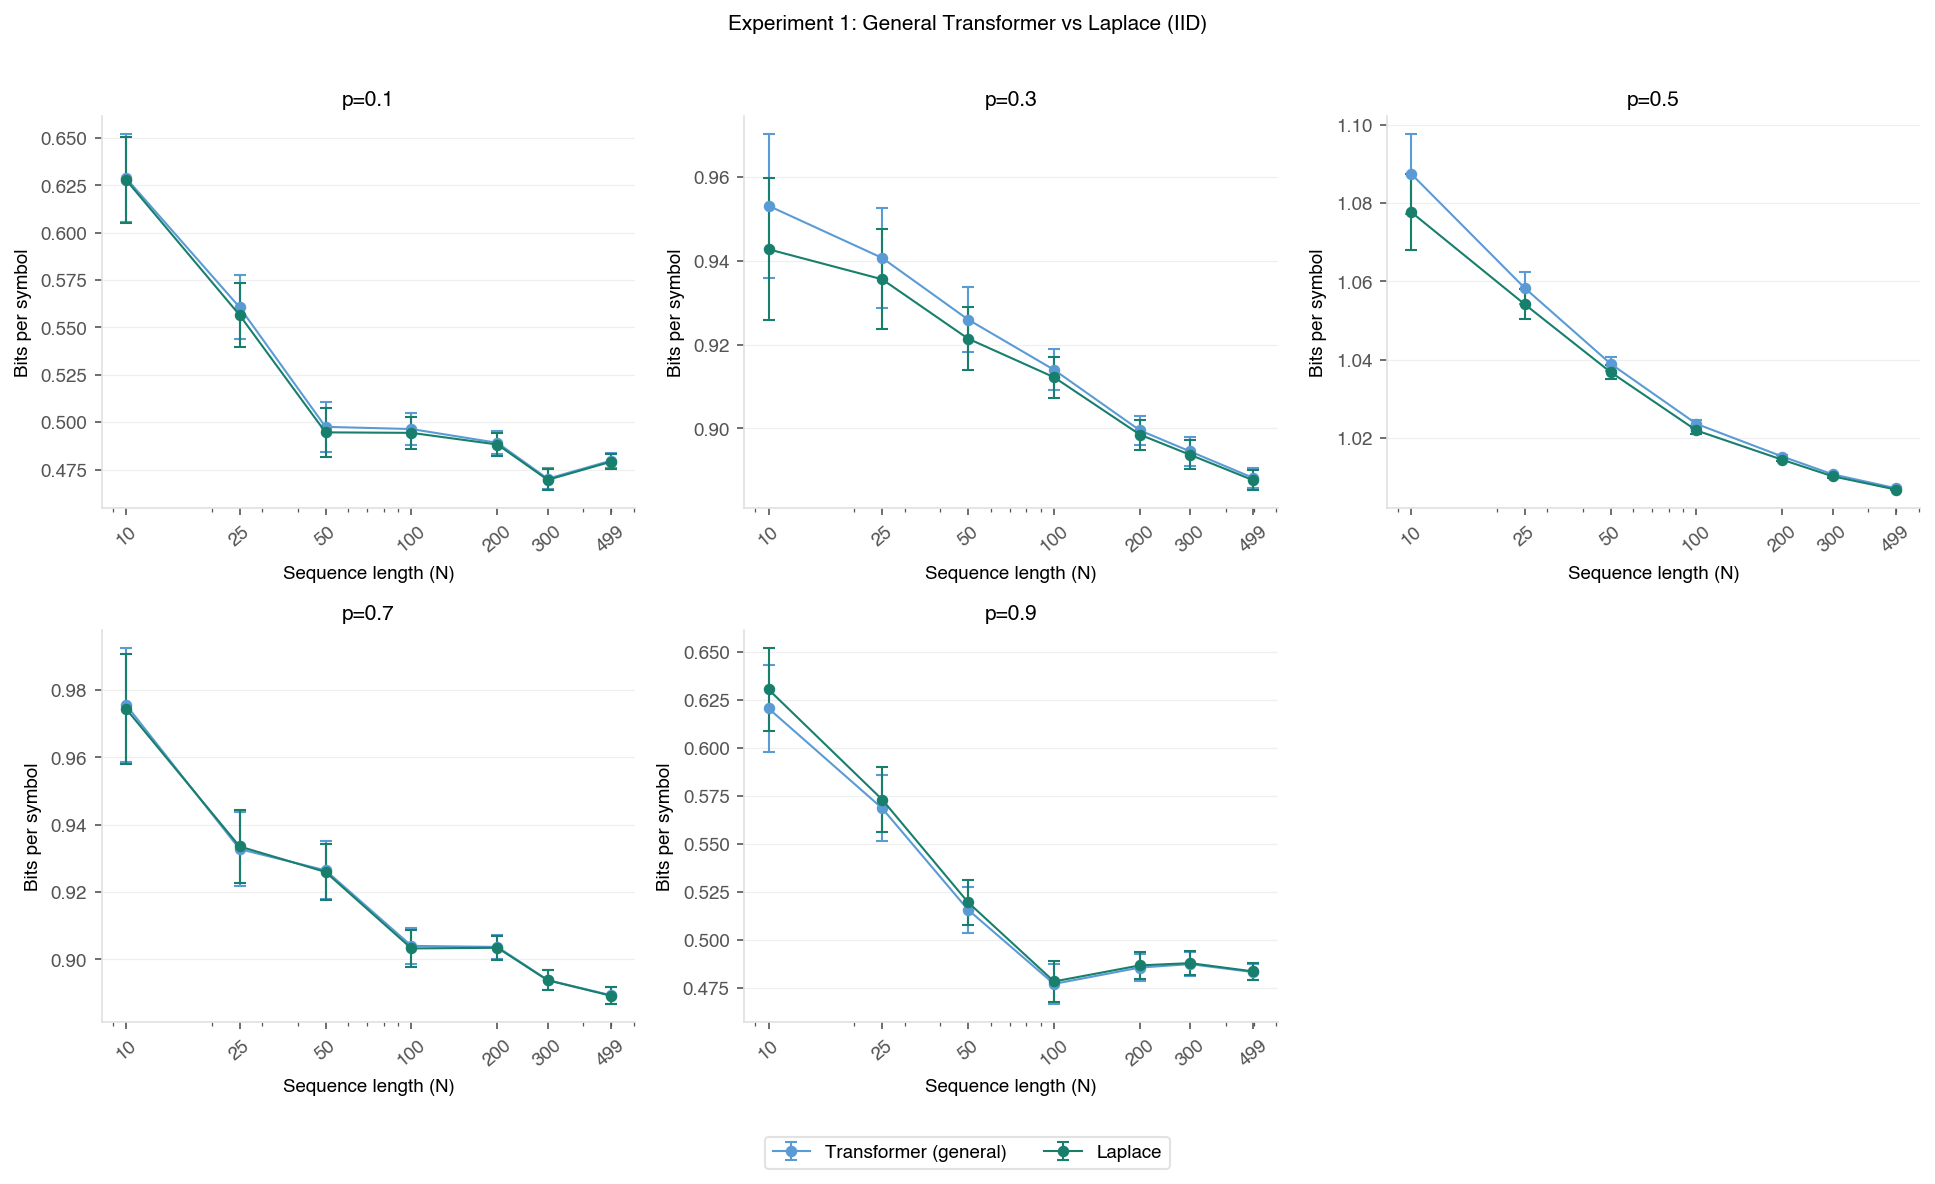

In [12]:
iid_exp1 = {}
for p in P_VALUES:
    iid_exp1[p] = {}
    for N in N_VALUES:
        raw = iid_results_raw[p][N]
        iid_exp1[p][N] = {
            'laplace':     {'mean': raw['laplace'][0],     'se': raw['laplace'][1]/NUM_TEST**0.5},
            'transformer': {'mean': raw['transformer'][0], 'se': raw['transformer'][1]/NUM_TEST**0.5},
            'entropy':     raw['entropy'],
        }

plot_bps_grid(
    iid_exp1, P_VALUES, 'p',
    [('transformer', 'Transformer (general)'), ('laplace', 'Laplace')],
    [C_IID, C_LAPLACE],
    'Experiment 1: General Transformer vs Laplace (IID)',
    '../notebooks/IID/figures/iid_bps_per_p.pdf',
)


## Experiment 2: Specialized Transformer Beats Laplace at Short Sequences

In [13]:
P03_MODEL_PATH = '../notebooks/IID/models/p03_model.pt'
P07_MODEL_PATH = '../notebooks/IID/models/p07_model.pt'
P03_EXP_PATH   = '../notebooks/IID/experiments/p03_experiment.pkl'
P07_EXP_PATH   = '../notebooks/IID/experiments/p07_experiment.pkl'

p03_dataset = FixedModelDataset(p=0.3, n=SEQ_LEN, num_samples=NUM_SAMPLES)
p07_dataset = FixedModelDataset(p=0.7, n=SEQ_LEN, num_samples=NUM_SAMPLES)
p03_model = train_or_load(P03_MODEL_PATH, p03_dataset)
p07_model = train_or_load(P07_MODEL_PATH, p07_dataset)


Loaded ../notebooks/IID/models/p03_model.pt
number of parameters: 0.11M
Loaded ../notebooks/IID/models/p07_model.pt
number of parameters: 0.11M


In [14]:
def load_or_run_specialized(exp_path, model, p_val, iid_model_ref):
    if os.path.exists(exp_path):
        with open(exp_path, 'rb') as f:
            raw = pickle.load(f)
        print('Loaded', exp_path)
        return raw
    raw = {p_val: {}}
    ent = -p_val*np.log2(p_val)-(1-p_val)*np.log2(1-p_val)
    for N in N_VALUES:
        lap_t, tr_t, gen_t = [], [], []
        for _ in range(NUM_TEST):
            seq = sample_iid(p_val, N)
            lap_t.append(sequential_bps(seq, laplace_p_array(seq)))
            tr_t.append(sequential_bps(seq, transformer_p_array(seq, model)))
            gen_t.append(sequential_bps(seq, transformer_p_array(seq, iid_model_ref)))
        raw[p_val][N] = {
            'laplace':     (float(np.mean(lap_t)), float(np.std(lap_t))),
            'transformer': (float(np.mean(tr_t)),  float(np.std(tr_t))),
            'general':     (float(np.mean(gen_t)), float(np.std(gen_t))),
            'entropy':     ent,
        }
    with open(exp_path, 'wb') as f:
        pickle.dump(raw, f)
    print('Saved', exp_path)
    return raw

p03_raw = load_or_run_specialized(P03_EXP_PATH, p03_model, 0.3, iid_model)
p07_raw = load_or_run_specialized(P07_EXP_PATH, p07_model, 0.7, iid_model)

print(f'p=0.3 N=10: specialized={p03_raw[0.3][10]["transformer"][0]:.3f}  Laplace={p03_raw[0.3][10]["laplace"][0]:.3f}  gap={p03_raw[0.3][10]["laplace"][0]-p03_raw[0.3][10]["transformer"][0]:.3f}')
print(f'p=0.3 N=499: gap={p03_raw[0.3][499]["laplace"][0]-p03_raw[0.3][499]["transformer"][0]:.3f}')


Loaded ../notebooks/IID/experiments/p03_experiment.pkl
Loaded ../notebooks/IID/experiments/p07_experiment.pkl
p=0.3 N=10: specialized=0.910  Laplace=0.976  gap=0.066
p=0.3 N=499: gap=0.007


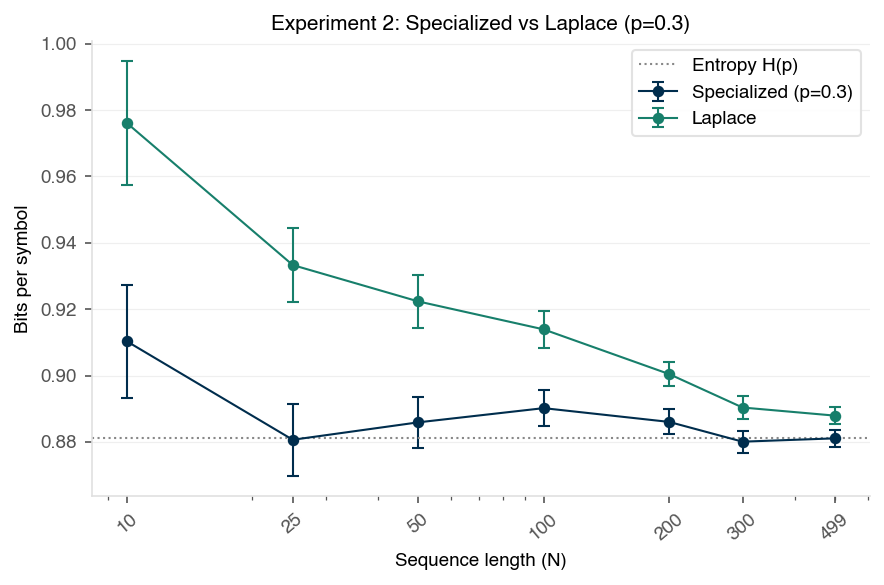

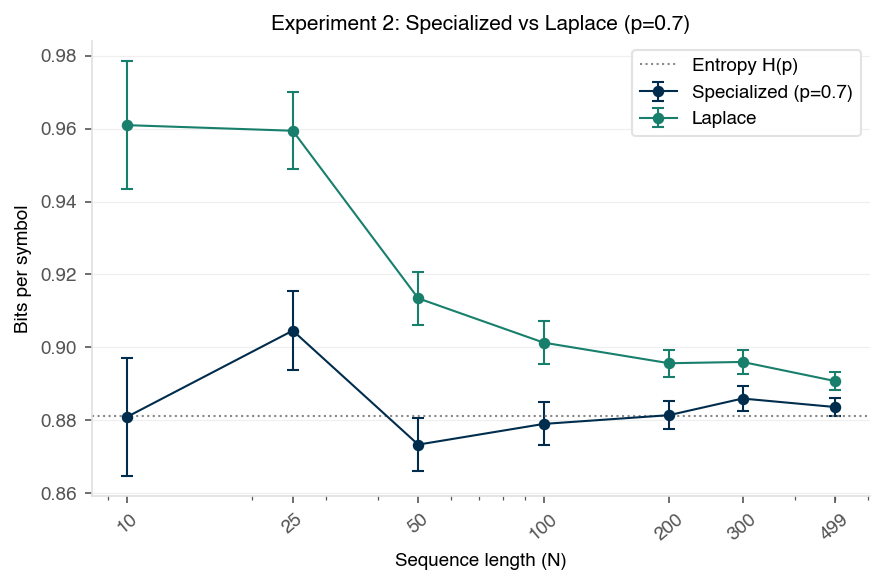

In [15]:
for p_val, raw, save_path in [
    (0.3, p03_raw, '../notebooks/IID/figures/iid_p03.pdf'),
    (0.7, p07_raw, '../notebooks/IID/figures/iid_p07.pdf'),
]:
    exp = {N: {
        'specialized': {'mean': raw[p_val][N]['transformer'][0], 'se': raw[p_val][N]['transformer'][1]/NUM_TEST**0.5},
        'laplace':     {'mean': raw[p_val][N]['laplace'][0],     'se': raw[p_val][N]['laplace'][1]/NUM_TEST**0.5},
    } for N in N_VALUES}
    plot_bps_single(
        exp, N_VALUES,
        [('specialized', f'Specialized (p={p_val})'), ('laplace', 'Laplace')],
        [C_SPECIALIZED, C_LAPLACE],
        entropy=-p_val*np.log2(p_val)-(1-p_val)*np.log2(1-p_val),
        title=f'Experiment 2: Specialized vs Laplace (p={p_val})',
        save_path=save_path,
    )


## Experiment 3: Redundancy Scales as 1/m

In [16]:
BENCH_PKL = '../notebooks/train_bounds/experiments/benchmark_results.pkl'

if os.path.exists(BENCH_PKL):
    with open(BENCH_PKL, 'rb') as f:
        bench_data = pickle.load(f)
    print('Loaded', BENCH_PKL)
else:
    P_TRUE = 0.3
    N_EVAL = 100
    N_TRIALS = 500
    entropy = -P_TRUE*np.log2(P_TRUE)-(1-P_TRUE)*np.log2(1-P_TRUE)

    lap_trials = [sequential_bps(sample_iid(P_TRUE, N_EVAL), laplace_p_array(sample_iid(P_TRUE, N_EVAL))) for _ in range(N_TRIALS)]
    laplace_redundancy = float(np.mean(lap_trials)) - entropy

    benchmark_transformer = {}
    for m in M_VALUES:
        path = f'../notebooks/train_bounds/models/benchmark_{m}.pt'
        ds = FixedModelDataset(p=P_TRUE, n=SEQ_LEN, num_samples=m)
        model = train_or_load(path, ds, iters=500)
        bps_t = [sequential_bps(sample_iid(P_TRUE, N_EVAL), transformer_p_array(sample_iid(P_TRUE, N_EVAL), model)) for _ in range(N_TRIALS)]
        benchmark_transformer[m] = float(np.mean(bps_t)) - entropy
        print(f'm={m}: redundancy={benchmark_transformer[m]:.4f}  laplace={laplace_redundancy:.4f}')

    bench_data = {'transformer': benchmark_transformer, 'laplace': laplace_redundancy}
    with open(BENCH_PKL, 'wb') as f:
        pickle.dump(bench_data, f)
    print('Saved', BENCH_PKL)

bench_m_vals = sorted(bench_data['transformer'].keys())
print(f'm=50:  {bench_data["transformer"][50]:.3f}')
print(f'm=100: {bench_data["transformer"][100]:.3f} (laplace={bench_data["laplace"]:.3f})')
print(f'm=150: {bench_data["transformer"][150]:.3f}')


Loaded ../notebooks/train_bounds/experiments/benchmark_results.pkl
m=50:  0.040
m=100: 0.021 (laplace=0.022)
m=150: 0.012


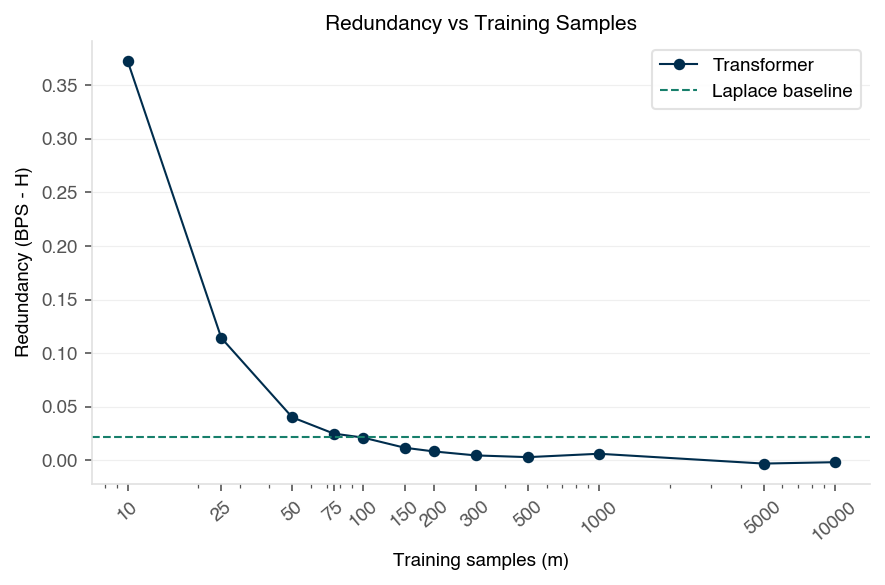

In [17]:
plot_redundancy_loglog(
    bench_data['transformer'],
    bench_data['laplace'],
    bench_m_vals,
    '../notebooks/train_bounds/figures/redundancy_vs_training.pdf',
)


## Experiment 4: Beta Prior Generalization

In [33]:
BETA_EXP_PATH = '../notebooks/ML/experiments/prior_sweep_results.pkl'

beta_models = {}
for alpha, beta in BETA_PRIORS:
    a_str = str(alpha).replace('.', 'p')
    b_str = str(beta).replace('.', 'p')
    path = f'../notebooks/ML/models/beta_{a_str}_{b_str}_model.pt'
    ds = BetaIIDDataset(alpha, beta, seq_len=SEQ_LEN, num_samples=NUM_SAMPLES)
    beta_models[(alpha, beta)] = train_or_load(path, ds, iters=500)


Training -> ../notebooks/ML/models/beta_1p0_1p0_model.pt
number of parameters: 0.11M
running on device mps


/Users/danvu/Documents/Spring 2026/Compression basics/.venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


  iter 0: loss 0.68112
  iter 100: loss 0.44781
  iter 200: loss 0.52267
  iter 300: loss 0.49724
  iter 400: loss 0.50250
Saved ../notebooks/ML/models/beta_1p0_1p0_model.pt
Training -> ../notebooks/ML/models/beta_0p5_0p5_model.pt
number of parameters: 0.11M
running on device mps
  iter 0: loss 0.65992
  iter 100: loss 0.40105
  iter 200: loss 0.42959
  iter 300: loss 0.37938
  iter 400: loss 0.37359
Saved ../notebooks/ML/models/beta_0p5_0p5_model.pt
Training -> ../notebooks/ML/models/beta_5p0_5p0_model.pt
number of parameters: 0.11M
running on device mps
  iter 0: loss 0.69957
  iter 100: loss 0.64745
  iter 200: loss 0.64512
  iter 300: loss 0.65064
  iter 400: loss 0.65507
Saved ../notebooks/ML/models/beta_5p0_5p0_model.pt
Training -> ../notebooks/ML/models/beta_5p0_2p0_model.pt
number of parameters: 0.11M
running on device mps
  iter 0: loss 0.66599
  iter 100: loss 0.54888
  iter 200: loss 0.53675
  iter 300: loss 0.53749
  iter 400: loss 0.55381
Saved ../notebooks/ML/models/beta_

In [34]:
BETA_N_VALUES = [10, 25, 50, 100, 200, 499]

if os.path.exists(BETA_EXP_PATH):
    with open(BETA_EXP_PATH, 'rb') as f:
        beta_results = pickle.load(f)
    BETA_N_VALUES = sorted(beta_results[BETA_PRIORS[0]].keys())
    print('Loaded', BETA_EXP_PATH)
else:
    beta_results = {}
    for alpha, beta in BETA_PRIORS:
        model = beta_models[(alpha, beta)]
        summary = {N: {'laplace':[], 'ctw':[], 'transformer':[], 'bayes_optimal':[]} for N in BETA_N_VALUES}
        for _ in range(NUM_TEST_BETA):
            p = np.random.beta(alpha, beta)
            full = np.random.binomial(1, p, max(BETA_N_VALUES)+1).tolist()
            lap_f  = bayes_optimal_p_array(full, 1.0, 1.0)
            bay_f  = bayes_optimal_p_array(full, alpha, beta)
            tr_f   = transformer_p_array(full, model)
            ctw_f  = ctw_p_array(full)
            for N in BETA_N_VALUES:
                seq = full[:N]
                summary[N]['laplace'].append(sequential_bps(seq, lap_f[:N]))
                summary[N]['ctw'].append(sequential_bps(seq, ctw_f[:N]))
                summary[N]['transformer'].append(sequential_bps(seq, tr_f[:N]))
                summary[N]['bayes_optimal'].append(sequential_bps(seq, bay_f[:N]))
        beta_results[(alpha, beta)] = {
            N: {k: {'mean': float(np.mean(v)), 'std': float(np.std(v)),
                     'ci': float(1.96*np.std(v)/len(v)**0.5)}
                for k, v in summary[N].items()}
            for N in BETA_N_VALUES
        }
    with open(BETA_EXP_PATH, 'wb') as f:
        pickle.dump(beta_results, f)
    print('Saved', BETA_EXP_PATH)

r11 = beta_results[(1.0,1.0)]
r55 = beta_results[(5.0,5.0)]
r52 = beta_results[(5.0,2.0)]
print(f'Beta(1,1) N=10: transformer={r11[10]["transformer"]["mean"]:.3f}  laplace={r11[10]["laplace"]["mean"]:.3f}')
print(f'Beta(5,5) N=10: transformer={r55[10]["transformer"]["mean"]:.3f}  laplace={r55[10]["laplace"]["mean"]:.3f}')
print(f'Beta(5,2) N=10: transformer={r52[10]["transformer"]["mean"]:.3f}  laplace={r52[10]["laplace"]["mean"]:.3f}')


Saved ../notebooks/ML/experiments/prior_sweep_results.pkl
Beta(1,1) N=10: transformer=0.718  laplace=0.827
Beta(5,5) N=10: transformer=0.921  laplace=1.023
Beta(5,2) N=10: transformer=0.792  laplace=0.888


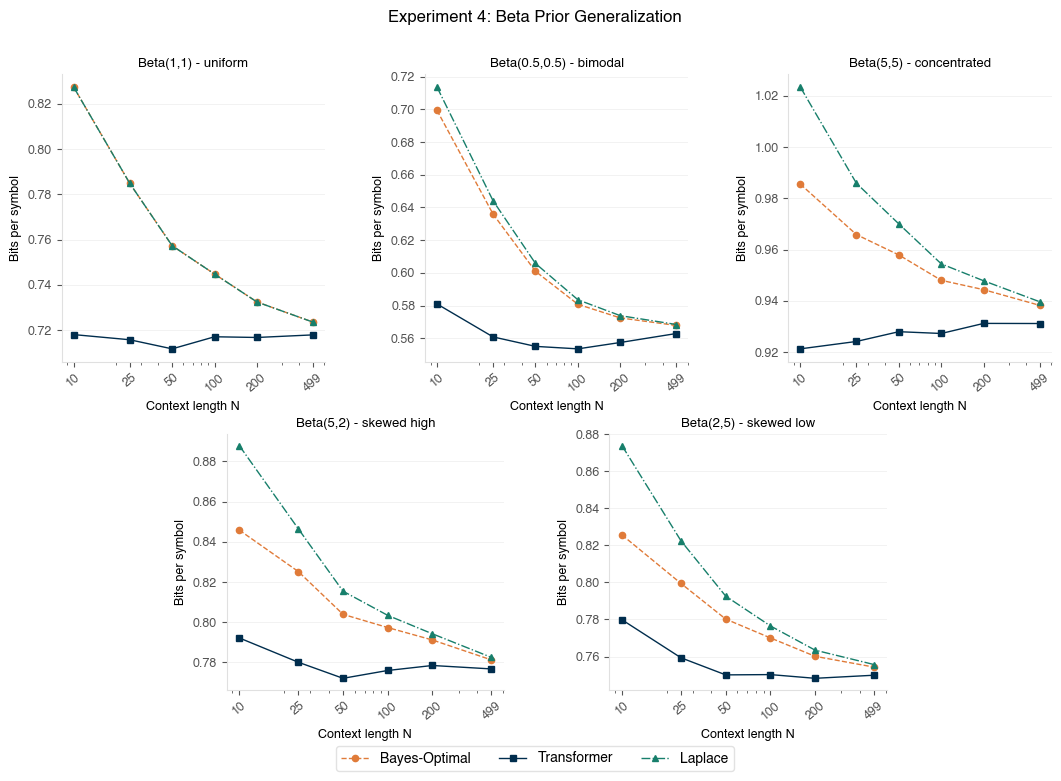

In [35]:
import matplotlib.gridspec as gridspec

PRIOR_LABELS = {
    (1.0,1.0): 'Beta(1,1) - uniform',
    (0.5,0.5): 'Beta(0.5,0.5) - bimodal',
    (5.0,5.0): 'Beta(5,5) - concentrated',
    (5.0,2.0): 'Beta(5,2) - skewed high',
    (2.0,5.0): 'Beta(2,5) - skewed low',
}

fig = plt.figure(figsize=(11, 8))
fig.patch.set_facecolor(BG)
gs_top = gridspec.GridSpec(1, 3, top=0.89, bottom=0.53, left=0.07, right=0.97, wspace=0.38)
gs_bot = gridspec.GridSpec(1, 2, top=0.44, bottom=0.12, left=0.22, right=0.82, wspace=0.38)
all_axes = [fig.add_subplot(gs_top[0, i]) for i in range(3)] + \
           [fig.add_subplot(gs_bot[0, i]) for i in range(2)]

for ax, (alpha, beta) in zip(all_axes, BETA_PRIORS):
    s = beta_results[(alpha, beta)]
    ns = BETA_N_VALUES
    for key, color, ls, marker, lbl in [
        ('bayes_optimal', C_BAYES,       '--', 'o', 'Bayes-Optimal'),
        ('transformer',   C_SPECIALIZED, '-',  's', 'Transformer'),
        ('laplace',       C_LAPLACE,     '-.',  '^', 'Laplace'),
    ]:
        means = [s[N][key]['mean'] for N in ns]
        ax.plot(ns, means, color=color, lw=1.0, ls=ls, marker=marker, ms=4.5, label=lbl)
    set_log_xticks(ax, ns)
    ax.set_xlabel('Context length N', fontsize=9)
    ax.set_ylabel('Bits per symbol', fontsize=9)
    ax.set_title(PRIOR_LABELS[(alpha, beta)], fontsize=9.5, pad=5)
    style_ax(ax)

handles, labels = all_axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=4,
           bbox_to_anchor=(0.5, 0.01), frameon=True, fontsize=10)
fig.suptitle('Experiment 4: Beta Prior Generalization', fontsize=12, fontweight='bold', y=0.97)
os.makedirs('../notebooks/ML/figures', exist_ok=True)
plt.savefig('../notebooks/ML/figures/fig1_bps_overview.pdf', bbox_inches='tight', dpi=150)
plt.show()


## Experiment 5: Binary Symmetric Markov Chain

In [21]:
MARKOV_SPEC_PKL = '../notebooks/Markov/experiments/specialized_experiment_markov.pkl'
MARKOV_IID_PKL  = '../notebooks/Markov/experiments/iid_experiment_markov.pkl'

markov_models = {}
for p_stay in P_STAY_VALUES:
    path = f'../notebooks/Markov/models/markov_{p_stay}_model.pt'
    ds = MarkovDataset(p_stay=p_stay, n=SEQ_LEN, num_samples=NUM_SAMPLES)
    markov_models[p_stay] = train_or_load(path, ds)


Loaded ../notebooks/Markov/models/markov_0.0_model.pt
number of parameters: 0.11M
Loaded ../notebooks/Markov/models/markov_0.3_model.pt
number of parameters: 0.11M
Loaded ../notebooks/Markov/models/markov_0.5_model.pt
number of parameters: 0.11M
Loaded ../notebooks/Markov/models/markov_0.7_model.pt
number of parameters: 0.11M
Loaded ../notebooks/Markov/models/markov_0.9_model.pt
number of parameters: 0.11M
Loaded ../notebooks/Markov/models/markov_0.99_model.pt
number of parameters: 0.11M


In [22]:
if os.path.exists(MARKOV_SPEC_PKL):
    with open(MARKOV_SPEC_PKL, 'rb') as f:
        spec_markov = pickle.load(f)
    print('Loaded', MARKOV_SPEC_PKL)
else:
    spec_markov = {}
    for p_stay in P_STAY_VALUES:
        model = markov_models[p_stay]
        spec_markov[p_stay] = {}
        for N in N_VALUES:
            lap_t, tr_t, ctw_t = [], [], []
            for _ in range(NUM_TEST):
                seq = sample_markov(p_stay, N)
                lap_t.append(sequential_bps(seq, laplace_p_array(seq)))
                tr_t.append(sequential_bps(seq, transformer_p_array(seq, model)))
                ctw_t.append(sequential_bps(seq, ctw_p_array(seq)))
            spec_markov[p_stay][N] = {
                'laplace':     (float(np.mean(lap_t)), float(np.std(lap_t))),
                'transformer': (float(np.mean(tr_t)),  float(np.std(tr_t))),
                'ctw':         (float(np.mean(ctw_t)), float(np.std(ctw_t))),
            }
    with open(MARKOV_SPEC_PKL, 'wb') as f:
        pickle.dump(spec_markov, f)
    print('Saved', MARKOV_SPEC_PKL)

if os.path.exists(MARKOV_IID_PKL):
    with open(MARKOV_IID_PKL, 'rb') as f:
        iid_markov = pickle.load(f)
    print('Loaded', MARKOV_IID_PKL)
else:
    iid_markov = {}
    for p_stay in P_STAY_VALUES:
        iid_markov[p_stay] = {}
        for N in N_VALUES:
            lap_t, tr_t, ctw_t = [], [], []
            for _ in range(NUM_TEST):
                seq = sample_markov(p_stay, N)
                lap_t.append(sequential_bps(seq, laplace_p_array(seq)))
                tr_t.append(sequential_bps(seq, transformer_p_array(seq, iid_model)))
                ctw_t.append(sequential_bps(seq, ctw_p_array(seq)))
            iid_markov[p_stay][N] = {
                'laplace':     (float(np.mean(lap_t)), float(np.std(lap_t))),
                'transformer': (float(np.mean(tr_t)),  float(np.std(tr_t))),
                'ctw':         (float(np.mean(ctw_t)), float(np.std(ctw_t))),
            }
    with open(MARKOV_IID_PKL, 'wb') as f:
        pickle.dump(iid_markov, f)
    print('Saved', MARKOV_IID_PKL)

print(f'p_stay=0.99 N=10: Laplace={iid_markov[0.99][10]["laplace"][0]:.3f}  IID_tr={iid_markov[0.99][10]["transformer"][0]:.3f}  CTW={iid_markov[0.99][10]["ctw"][0]:.3f}')
print(f'p_stay=0.99 N=50: CTW={iid_markov[0.99][50]["ctw"][0]:.3f}')


Loaded ../notebooks/Markov/experiments/specialized_experiment_markov.pkl
Loaded ../notebooks/Markov/experiments/iid_experiment_markov.pkl
p_stay=0.99 N=10: Laplace=0.406  IID_tr=0.389  CTW=1.000
p_stay=0.99 N=50: CTW=0.346


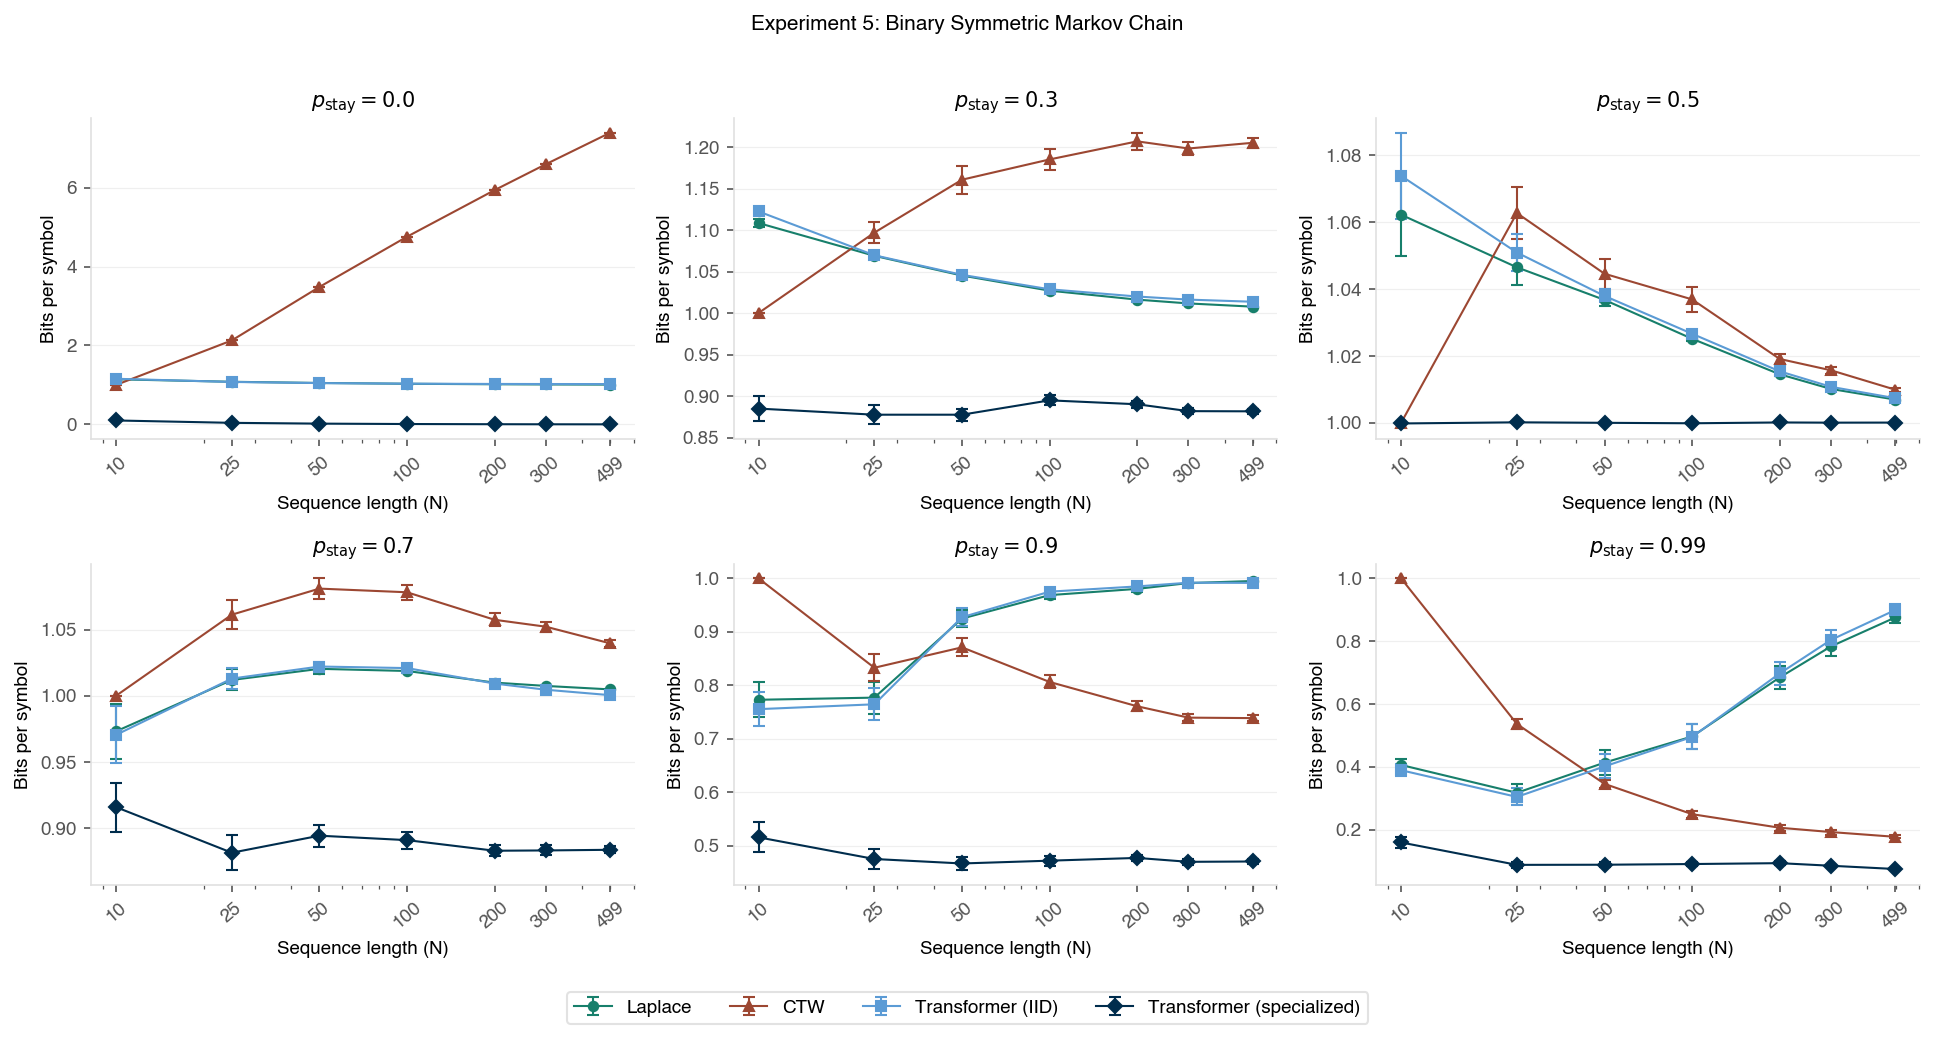

In [23]:
fig, axes = plt.subplots(2, 3, figsize=(13, 7), dpi=150)
fig.patch.set_facecolor(BG)
axes = axes.flatten()

for idx, p_stay in enumerate(P_STAY_VALUES):
    ax = axes[idx]
    iid_d  = iid_markov[p_stay]
    spec_d = spec_markov[p_stay]
    lap_m   = [iid_d[N]['laplace'][0]      for N in N_VALUES]
    iid_m   = [iid_d[N]['transformer'][0]  for N in N_VALUES]
    ctw_m   = [iid_d[N]['ctw'][0]          for N in N_VALUES]
    spec_m  = [spec_d[N]['transformer'][0] for N in N_VALUES]
    lap_se  = [iid_d[N]['laplace'][1]      / NUM_TEST**0.5 for N in N_VALUES]
    iid_se  = [iid_d[N]['transformer'][1]  / NUM_TEST**0.5 for N in N_VALUES]
    ctw_se  = [iid_d[N]['ctw'][1]          / NUM_TEST**0.5 for N in N_VALUES]
    spec_se = [spec_d[N]['transformer'][1] / NUM_TEST**0.5 for N in N_VALUES]
    ax.errorbar(N_VALUES, lap_m,  yerr=lap_se,  fmt='o-', capsize=3, color=C_LAPLACE,     lw=1.0, ms=4.5, label='Laplace')
    ax.errorbar(N_VALUES, ctw_m,  yerr=ctw_se,  fmt='^-', capsize=3, color=C_CTW,         lw=1.0, ms=4.5, label='CTW')
    ax.errorbar(N_VALUES, iid_m,  yerr=iid_se,  fmt='s-', capsize=3, color=C_IID,         lw=1.0, ms=4.5, label='Transformer (IID)')
    ax.errorbar(N_VALUES, spec_m, yerr=spec_se, fmt='D-', capsize=3, color=C_SPECIALIZED, lw=1.0, ms=4.5, label='Transformer (specialized)')
    set_log_xticks(ax, N_VALUES)
    ax.set_title(f'$p_{{\\mathrm{{stay}}}}={p_stay}$', pad=5)
    ax.set_xlabel('Sequence length (N)', fontsize=9)
    ax.set_ylabel('Bits per symbol', fontsize=9)
    style_ax(ax)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=4,
           bbox_to_anchor=(0.5, 0.01), frameon=True, fontsize=9)
fig.suptitle('Experiment 5: Binary Symmetric Markov Chain', fontsize=10, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0.06, 1, 0.97])
os.makedirs('../notebooks/Markov/figures', exist_ok=True)
plt.savefig('../notebooks/Markov/figures/markov_bps_grid_comparison.png', bbox_inches='tight', dpi=150)
plt.show()


## Experiment 6: Dirichlet Markov Sweep

In [24]:
dirichlet_models = {}
for alpha in DIRICHLET_ALPHAS:
    path = f'../notebooks/Markov/models/fsm_{alpha}_model.pt'
    ds = DirichletMarkovDataset(alpha, FSM_EMISSION, n=SEQ_LEN, num_samples=NUM_SAMPLES)
    dirichlet_models[alpha] = train_or_load(path, ds, iters=500)


Loaded ../notebooks/Markov/models/fsm_0.1_model.pt
number of parameters: 0.11M
Loaded ../notebooks/Markov/models/fsm_0.5_model.pt
number of parameters: 0.11M
Loaded ../notebooks/Markov/models/fsm_1.0_model.pt
number of parameters: 0.11M
Loaded ../notebooks/Markov/models/fsm_2.0_model.pt
number of parameters: 0.11M
Loaded ../notebooks/Markov/models/fsm_5.0_model.pt
number of parameters: 0.11M
Loaded ../notebooks/Markov/models/fsm_10.0_model.pt
number of parameters: 0.11M


In [25]:
spec_fsm_results = {}
for alpha in DIRICHLET_ALPHAS:
    exp_path = f'../notebooks/Markov/experiments/fsm_{alpha}_experiment.pkl'
    if os.path.exists(exp_path):
        with open(exp_path, 'rb') as f:
            raw = pickle.load(f)
        spec_fsm_results[alpha] = raw[alpha]
        print(f'Loaded fsm_{alpha}_experiment.pkl')
    else:
        model = dirichlet_models[alpha]
        spec_fsm_results[alpha] = {}
        for N in N_VALUES:
            lap_t, tr_t, ctw_t = [], [], []
            for _ in range(NUM_TEST):
                seq = sample_dirichlet_markov(alpha, FSM_EMISSION, N)
                lap_t.append(sequential_bps(seq, laplace_p_array(seq)))
                tr_t.append(sequential_bps(seq, transformer_p_array(seq, model)))
                ctw_t.append(sequential_bps(seq, ctw_p_array(seq)))
            spec_fsm_results[alpha][N] = {
                'laplace':     (float(np.mean(lap_t)), float(np.std(lap_t))),
                'transformer': (float(np.mean(tr_t)),  float(np.std(tr_t))),
                'ctw':         (float(np.mean(ctw_t)), float(np.std(ctw_t))),
            }
        with open(exp_path, 'wb') as f:
            pickle.dump({alpha: spec_fsm_results[alpha]}, f)
        print(f'Saved fsm_{alpha}_experiment.pkl')

IID_FSM_PKL = '../notebooks/Markov/experiments/iid_model_fsm_alpha_sweep.pkl'
if os.path.exists(IID_FSM_PKL):
    with open(IID_FSM_PKL, 'rb') as f:
        iid_fsm_results = pickle.load(f)
    print('Loaded', IID_FSM_PKL)
else:
    iid_fsm_results = {}
    for alpha in DIRICHLET_ALPHAS:
        iid_fsm_results[alpha] = {}
        for N in N_VALUES:
            lap_t, tr_t, ctw_t = [], [], []
            for _ in range(NUM_TEST):
                seq = sample_dirichlet_markov(alpha, FSM_EMISSION, N)
                lap_t.append(sequential_bps(seq, laplace_p_array(seq)))
                tr_t.append(sequential_bps(seq, transformer_p_array(seq, iid_model)))
                ctw_t.append(sequential_bps(seq, ctw_p_array(seq)))
            iid_fsm_results[alpha][N] = {
                'laplace':     (float(np.mean(lap_t)), float(np.std(lap_t))),
                'transformer': (float(np.mean(tr_t)),  float(np.std(tr_t))),
                'ctw':         (float(np.mean(ctw_t)), float(np.std(ctw_t))),
            }
    with open(IID_FSM_PKL, 'wb') as f:
        pickle.dump(iid_fsm_results, f)
    print('Saved', IID_FSM_PKL)

alpha = 1.0
print(f'alpha=1.0 N=100: specialized={spec_fsm_results[alpha][100]["transformer"][0]:.3f}  Laplace={spec_fsm_results[alpha][100]["laplace"][0]:.3f}  CTW={spec_fsm_results[alpha][100]["ctw"][0]:.3f}')


Loaded fsm_0.1_experiment.pkl
Loaded fsm_0.5_experiment.pkl
Loaded fsm_1.0_experiment.pkl
Loaded fsm_2.0_experiment.pkl
Loaded fsm_5.0_experiment.pkl
Loaded fsm_10.0_experiment.pkl
Loaded ../notebooks/Markov/experiments/iid_model_fsm_alpha_sweep.pkl
alpha=1.0 N=100: specialized=0.994  Laplace=1.009  CTW=1.022


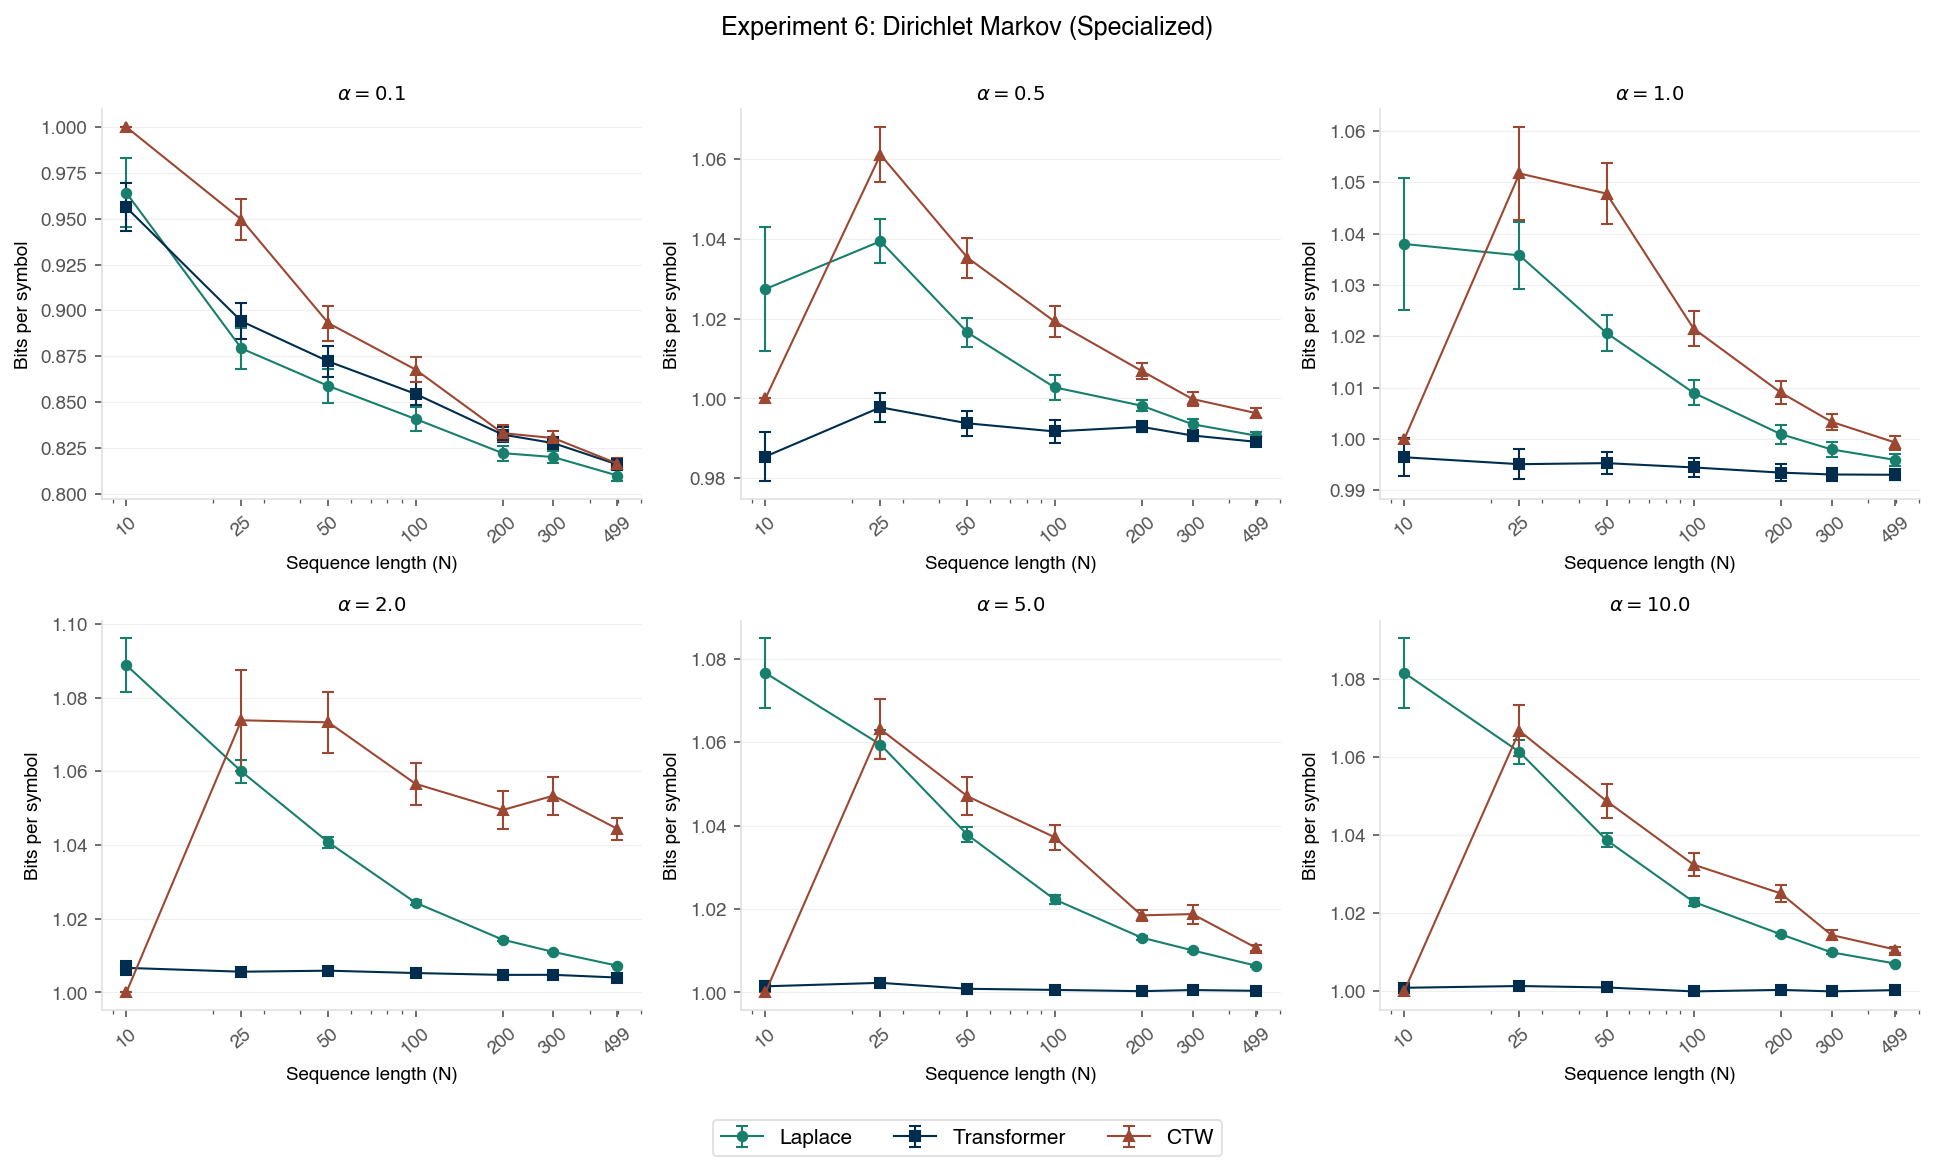

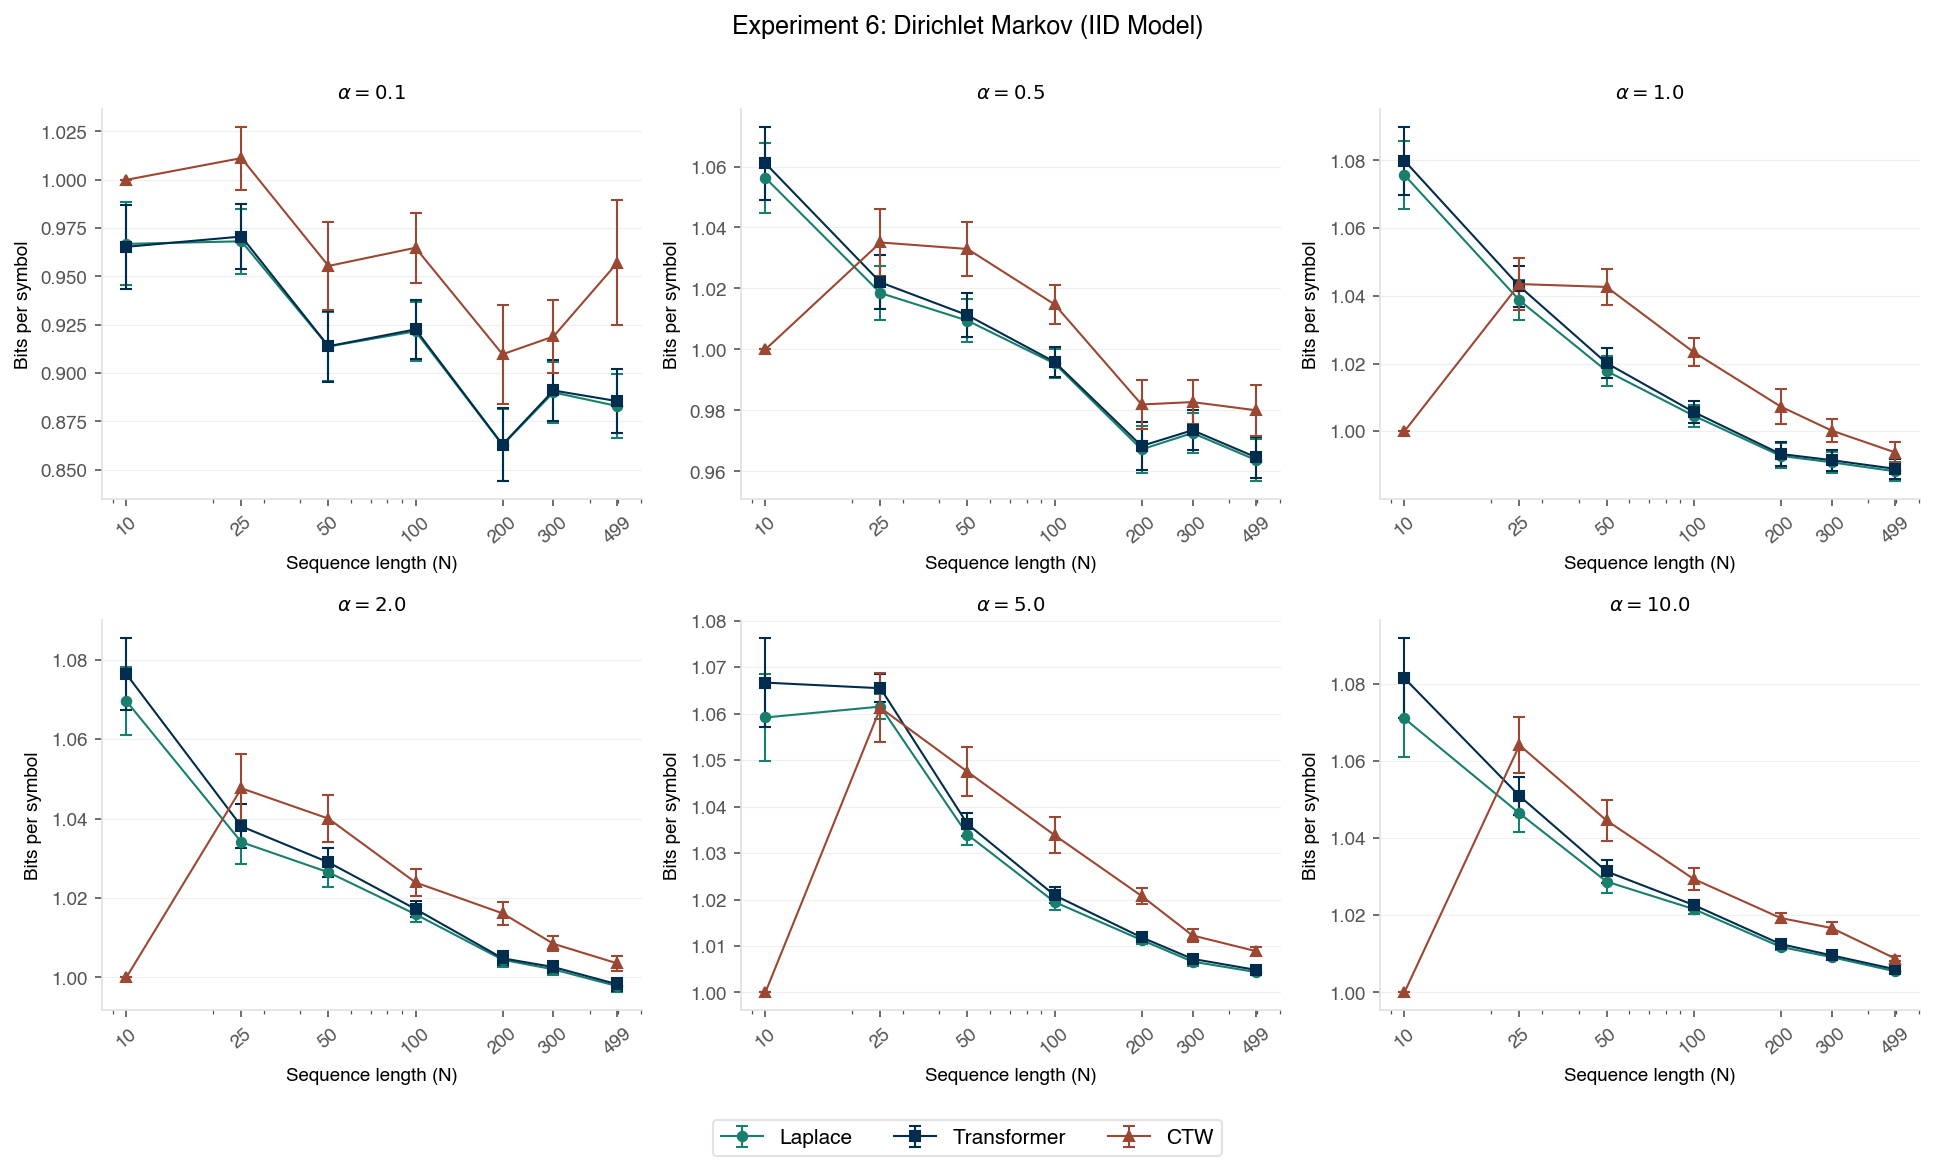

In [26]:
def _get_mean_se(d, N, key, n_trials):
    v = d[N][key]
    if isinstance(v, tuple):
        return v[0], v[1]/n_trials**0.5
    return v['mean'], v.get('se', v.get('std', 0)/n_trials**0.5)

for results, title, save_stem in [
    (spec_fsm_results, 'Experiment 6: Dirichlet Markov (Specialized)', 'fsm_bps_grid_specialized'),
    (iid_fsm_results,  'Experiment 6: Dirichlet Markov (IID Model)',   'fsm_bps_grid_iid'),
]:
    fig, axes = plt.subplots(2, 3, figsize=(13, 8), dpi=150)
    fig.patch.set_facecolor(BG)
    axes = axes.flatten()
    for idx, alpha in enumerate(DIRICHLET_ALPHAS):
        ax = axes[idx]
        d = results[alpha]
        for key, color, marker, lbl in [
            ('laplace', C_LAPLACE, 'o', 'Laplace'),
            ('transformer', C_SPECIALIZED, 's', 'Transformer'),
            ('ctw', C_CTW, '^', 'CTW'),
        ]:
            means = [_get_mean_se(d, N, key, NUM_TEST)[0] for N in N_VALUES]
            ses   = [_get_mean_se(d, N, key, NUM_TEST)[1] for N in N_VALUES]
            ax.errorbar(N_VALUES, means, yerr=ses, fmt=f'{marker}-', capsize=3,
                        color=color, lw=1.0, ms=4.5, label=lbl)
        set_log_xticks(ax, N_VALUES)
        ax.set_title(f'$\\alpha={alpha}$', fontsize=9.5, pad=5)
        ax.set_xlabel('Sequence length (N)', fontsize=9)
        ax.set_ylabel('Bits per symbol', fontsize=9)
        style_ax(ax)
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', ncol=3,
               bbox_to_anchor=(0.5, 0.01), frameon=True, fontsize=10)
    fig.suptitle(title, fontsize=12, fontweight='bold', y=0.97)
    plt.tight_layout(rect=[0, 0.06, 1, 0.97])
    plt.savefig(f'../notebooks/Markov/figures/{save_stem}.pdf', bbox_inches='tight', dpi=150)
    plt.show()


## Experiment 7: Deterministic FSM Benchmark

In [27]:
FSM_MODEL_PATH = '../notebooks/Markov/models/fsm_final_model.pt'
FSM_BENCH_PKL  = '../notebooks/Markov/experiments/fsm_final_benchmark.pkl'

fsm_dataset = FSMDataset(FSM_EMISSION, FSM_T0, FSM_T1, seq_len=SEQ_LEN, num_samples=NUM_SAMPLES)
fsm_model = train_or_load(FSM_MODEL_PATH, fsm_dataset, iters=500)


Loaded ../notebooks/Markov/models/fsm_final_model.pt
number of parameters: 0.11M


In [28]:
if os.path.exists(FSM_BENCH_PKL):
    with open(FSM_BENCH_PKL, 'rb') as f:
        fsm_bench = pickle.load(f)
    print('Loaded', FSM_BENCH_PKL)
else:
    fsm_bench = {}
    for N in N_VALUES:
        lap_t, tr_t, ctw_t = [], [], []
        for _ in range(NUM_TEST):
            seq = generate_fsm_sequence(FSM_EMISSION, FSM_T0, FSM_T1, N)
            lap_t.append(sequential_bps(seq, laplace_p_array(seq)))
            tr_t.append(sequential_bps(seq, transformer_p_array(seq, fsm_model)))
            ctw_t.append(sequential_bps(seq, ctw_p_array(seq)))
        fsm_bench[N] = {
            'laplace':     (float(np.mean(lap_t)), float(np.std(lap_t))),
            'transformer': (float(np.mean(tr_t)),  float(np.std(tr_t))),
            'ctw':         (float(np.mean(ctw_t)), float(np.std(ctw_t))),
        }
    with open(FSM_BENCH_PKL, 'wb') as f:
        pickle.dump(fsm_bench, f)
    print('Saved', FSM_BENCH_PKL)

print(f'N=10:  tr={fsm_bench[10]["transformer"][0]:.3f}  lap={fsm_bench[10]["laplace"][0]:.3f}  ctw={fsm_bench[10]["ctw"][0]:.3f}')
print(f'N=499: tr={fsm_bench[499]["transformer"][0]:.3f}  ctw={fsm_bench[499]["ctw"][0]:.3f}  lap={fsm_bench[499]["laplace"][0]:.3f}')


Loaded ../notebooks/Markov/experiments/fsm_final_benchmark.pkl
N=10:  tr=0.760  lap=0.918  ctw=1.000
N=499: tr=0.746  ctw=0.798  lap=0.810


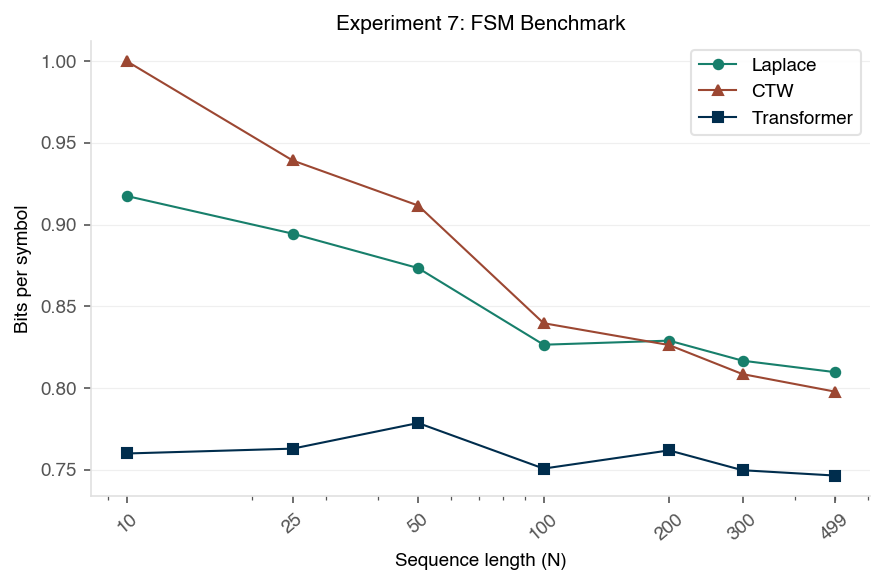

In [29]:
fig, ax = plt.subplots(figsize=(6, 4), dpi=150)
fig.patch.set_facecolor(BG)
for key, color, marker, lbl in [
    ('laplace',     C_LAPLACE,     'o', 'Laplace'),
    ('ctw',         C_CTW,         '^', 'CTW'),
    ('transformer', C_SPECIALIZED, 's', 'Transformer'),
]:
    v = fsm_bench
    means = [v[N][key][0] if isinstance(v[N][key], tuple) else v[N][key]['mean'] for N in N_VALUES]
    ax.plot(N_VALUES, means, color=color, lw=1.0, marker=marker, ms=4.5, label=lbl)
set_log_xticks(ax, N_VALUES)
ax.set_xlabel('Sequence length (N)', fontsize=9)
ax.set_ylabel('Bits per symbol', fontsize=9)
ax.set_title('Experiment 7: FSM Benchmark', pad=5)
ax.legend()
style_ax(ax)
plt.tight_layout()
plt.savefig('../notebooks/Markov/figures/fsm_benchmark.pdf', bbox_inches='tight', dpi=150)
plt.show()


## Experiment 8: Attention Head Probe

In [30]:
BETA_MODEL_REGISTRY = {
    'beta_0p5_0p5_model.pt': (0.5, 0.5),
    'beta_1p0_1p0_model.pt': (1.0, 1.0),
    'beta_2p0_5p0_model.pt': (2.0, 5.0),
    'beta_5p0_2p0_model.pt': (5.0, 2.0),
    'beta_5p0_5p0_model.pt': (5.0, 5.0),
}

probe_models = {}
for fname, (a, b) in BETA_MODEL_REGISTRY.items():
    path = f'../notebooks/ML/models/{fname}'
    probe_models[fname] = {'model': load_model(path), 'alpha': a, 'beta': b,
                            'label': f'Beta({a},{b})'}

rng_probe = np.random.default_rng(seed=42)
test_seqs = rng_probe.binomial(1, 0.5, size=(50, 499))

def _extract_attn(seq, model):
    x = torch.tensor(seq, dtype=torch.long, device=DEVICE).unsqueeze(0)
    with torch.no_grad():
        model(x)
    return np.array([model.transformer.h[l].attn._attn_output.squeeze(0).cpu().numpy()
                      for l in range(3)])

def _kt_targets(seqs):
    out = np.zeros_like(seqs, dtype=float)
    out[:, 0] = 0.5
    for t in range(1, seqs.shape[1]):
        out[:, t] = seqs[:, :t].sum(axis=1) / t
    return out

def _bayes_targets(seqs, alpha, beta):
    out = np.zeros_like(seqs, dtype=float)
    out[:, 0] = alpha / (alpha + beta)
    for t in range(1, seqs.shape[1]):
        k = seqs[:, :t].sum(axis=1)
        out[:, t] = (k + alpha) / (t + alpha + beta)
    return out

kt_flat = _kt_targets(test_seqs).flatten()


number of parameters: 0.11M
number of parameters: 0.11M
number of parameters: 0.11M
number of parameters: 0.11M
number of parameters: 0.11M


In [31]:
probe_r2    = {}
probe_r2_bay = {}

for fname, m_info in probe_models.items():
    model = m_info['model']
    alpha, beta = m_info['alpha'], m_info['beta']
    all_outs = np.array([_extract_attn(s, model) for s in test_seqs])  # [50,3,3,499,16]
    bay_flat = _bayes_targets(test_seqs, alpha, beta).flatten()
    kt_r2  = np.zeros((3, 3))
    bay_r2 = np.zeros((3, 3))
    for l in range(3):
        for h in range(3):
            X = all_outs[:, l, h, :, :].reshape(-1, 16)
            kt_r2[l, h]  = r2_score(kt_flat,  Ridge(alpha=1e-3).fit(X, kt_flat).predict(X))
            bay_r2[l, h] = r2_score(bay_flat, Ridge(alpha=1e-3).fit(X, bay_flat).predict(X))
    probe_r2[fname]     = kt_r2
    probe_r2_bay[fname] = bay_r2
    print(f"{m_info['label']}: kt_R2 layer-means={np.round(kt_r2.mean(1),3)}  bayes_R2 layer-means={np.round(bay_r2.mean(1),3)}")

best_bayes = {fname: probe_r2_bay[fname].max() for fname in probe_models}
print('Beta(5,2) max Bayes R2:', round(best_bayes['beta_5p0_2p0_model.pt'], 3))


Beta(0.5,0.5): kt_R2 layer-means=[0.407 0.107 0.213]  bayes_R2 layer-means=[0.429 0.082 0.209]
Beta(1.0,1.0): kt_R2 layer-means=[0.524 0.204 0.204]  bayes_R2 layer-means=[0.569 0.167 0.177]
Beta(2.0,5.0): kt_R2 layer-means=[0.656 0.384 0.339]  bayes_R2 layer-means=[0.743 0.49  0.44 ]
Beta(5.0,2.0): kt_R2 layer-means=[0.698 0.449 0.302]  bayes_R2 layer-means=[0.815 0.612 0.469]
Beta(5.0,5.0): kt_R2 layer-means=[0.659 0.675 0.617]  bayes_R2 layer-means=[0.683 0.758 0.658]
Beta(5,2) max Bayes R2: 0.853


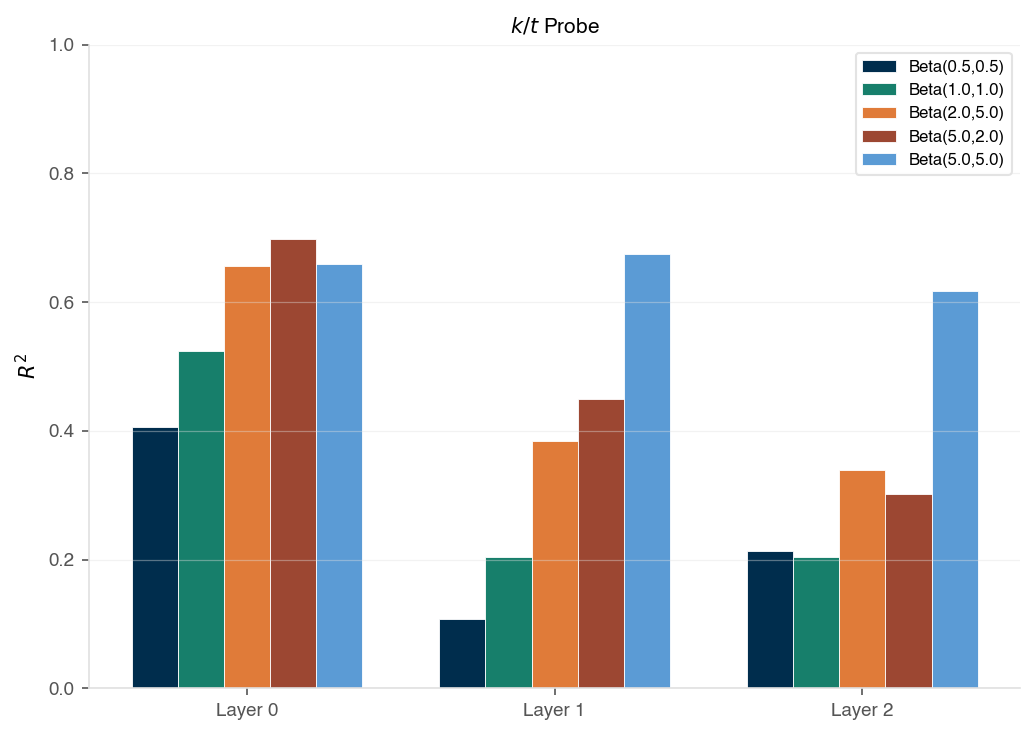

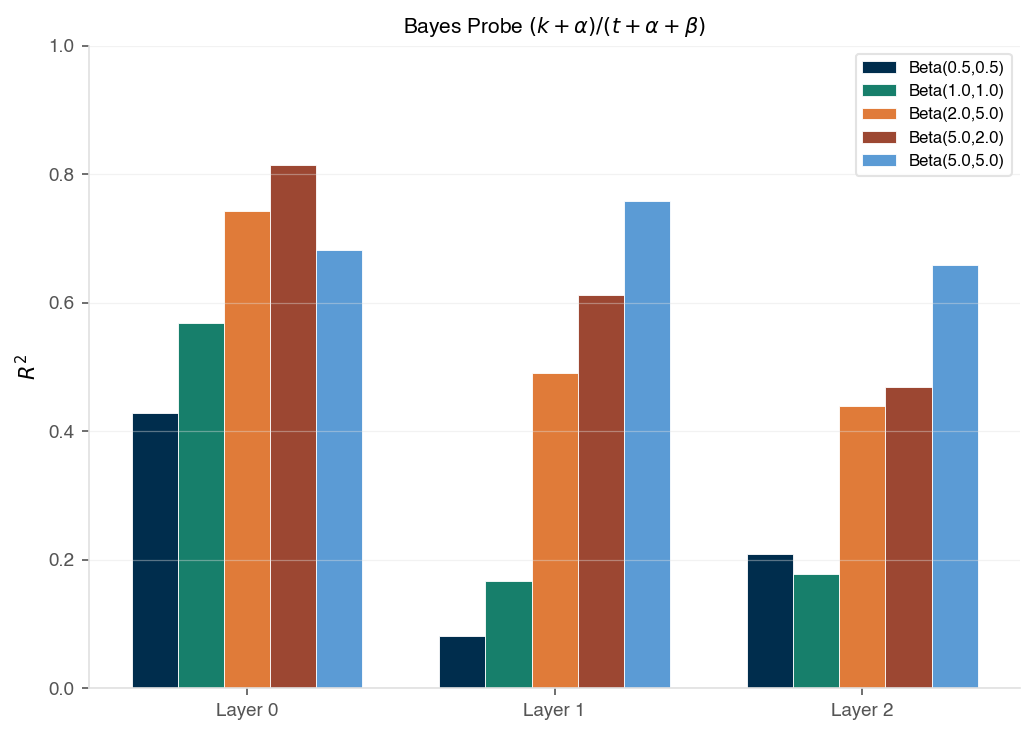

In [32]:
filenames = list(probe_models.keys())
labels    = [probe_models[f]['label'] for f in filenames]
colors_probe = [C_SPECIALIZED, C_LAPLACE, C_BAYES, C_CTW, C_IID]

plot_r2_bars(
    [probe_r2[f] for f in filenames], labels, colors_probe,
    r'$k/t$ Probe',
    '../notebooks/ML/figures/attention_r2.pdf',
)
plot_r2_bars(
    [probe_r2_bay[f] for f in filenames], labels, colors_probe,
    r'Bayes Probe $(k+\alpha)/(t+\alpha+\beta)$',
    '../notebooks/ML/figures/attention_r2_bayes.pdf',
)
